In [1]:
from fitburst.backend import general
import fitburst.routines as rt
import numpy as np
import scipy.special as ss

import os
import oscfar as ocf
import matplotlib.pyplot as plt
from fitburst.analysis.model import SpectrumModeler
import copy

In [2]:
reader = ocf.npz_reader("temp.npz")

In [3]:
freqs = reader.freqs
times = reader.times

In [4]:
upsample_freq = 1
upsample_time = 1

In [5]:
len(freqs), len(times)

(1024, 438)

In [6]:
current_amplitudes = np.array(reader.burst_parameters["amplitude"])
current_arrival_times = np.array(reader.burst_parameters["arrival_time"])
current_dm = reader.burst_parameters["dm"][0]
current_ref_freq = np.array(reader.burst_parameters["ref_freq"], dtype=float)
current_sc_idx = reader.burst_parameters["scattering_index"][0]
current_sc_time = reader.burst_parameters["scattering_timescale"][0]
current_sp_idx = np.array(reader.burst_parameters["spectral_index"])
current_sp_run = np.array(reader.burst_parameters["spectral_running"])
current_widths = np.array(reader.burst_parameters["burst_width"])


# current_ref_freq = np.array(current_ref_freq, dtype=float)
num_components = len(current_arrival_times)

### Some methods


In [7]:
def downsample_tile(orig, factors):
    if len(orig.shape) != len(factors):
        raise ValueError(
            f"Mismatch between number of factors and array shape: {len(factors)} vs {len(orig.shape)}"
        )
    shape_new = []
    pos = []
    for i, (f, s) in enumerate(zip(factors, orig.shape)):
        shape_new.append(s // f)
        shape_new.append(f)
        pos.append(i * 2 + 1)

    return np.mean(orig.reshape(shape_new), axis=tuple(pos))

In [8]:
def identify_pbf_regime(arg, threshold=-20.0):
    flag = arg > threshold  # if arg.ndim == 1 else np.all(arg > threshold)
    valid = np.flatnonzero(flag)
    invalid = np.flatnonzero(~flag) if valid.size < flag.size else None

    if valid.size == 0:
        valid = None
    elif (valid[-1] + 1 - valid[0]) == valid.size:
        valid = slice(valid[0], valid[-1] + 1)

    if invalid is not None and (invalid[-1] + 1 - invalid[0]) == invalid.size:
        invalid = slice(invalid[0], invalid[-1] + 1)

    return valid, invalid

### Testing


In [9]:
t = times

In [10]:
if t.ndim == 1:
    freq_dep_time = False
elif t.ndim == 2:
    freq_dep_time = True

#### Calculate the normal model first


In [11]:
modeler = SpectrumModeler(
    freqs,
    t,
    0,
    upsample_freq,
    upsample_time,
    len(reader.burst_parameters["arrival_time"]),
    True,
    False,
    False,
    True,
)

In [12]:
copy_param = copy.deepcopy(reader.burst_parameters)
copy_param["dm"] = [0]
copy_param["scattering_timescale"] = [copy_param["scattering_timescale"][0]]

modeler.update_parameters(copy_param)

In [80]:
modelfitburst = modeler.compute_model(data=reader.data_full)

ERROR MESSAGE BECAUSE IM GOING TO GIVE UP.
0.00000  -0.56361  0.00043   -4.00000  0.00022  0.00006 2.37841  -5.14895
0.00000  -1.44674  0.00019   -4.00000  0.00022  0.00035 7.77290  -11.71593


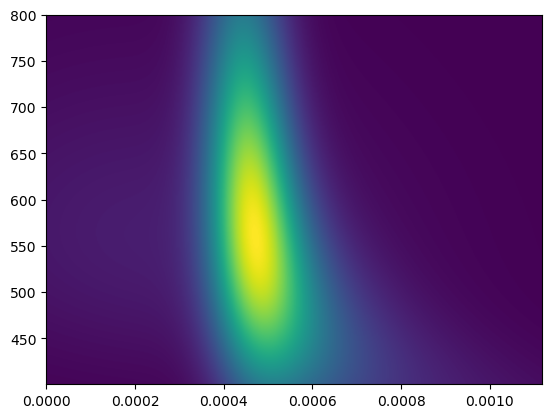

In [14]:
plt.imshow(
    modelfitburst,
    aspect="auto",
    extent=[times[0], times[-1], freqs[0], freqs[-1]],
    origin="lower",
)

#### Then try new version to see where it fucks up


In [15]:
current_freq_arr = rt.manipulate.upsample_1d(freqs, reader.res_freq, upsample_freq)

In [16]:
current_times = t
if freq_dep_time:
    current_times = np.repeat(current_times, upsample_freq, axis=0)
current_times = rt.manipulate.upsample_1d(
    current_times.T, reader.res_time, upsample_time
).T

In [17]:
dm_delay = rt.ism.compute_time_dm_delay(
    current_dm, general["constants"]["dispersion"], -2, current_freq_arr, 400
)

arrival_time_vs_freq = np.tile(
    np.array(current_arrival_times)[:, np.newaxis], (1, *current_freq_arr.shape)
) + np.tile(dm_delay[np.newaxis, :], (num_components, 1))

In [18]:
if freq_dep_time:
    current_times_arr = np.tile(
        current_times[np.newaxis, :, :], (num_components, 1, 1)
    ) - np.tile(arrival_time_vs_freq[:, :, np.newaxis], (1, 1, current_times.shape[-1]))

else:
    arrival_time_vs_freq -= np.repeat(
        rt.ism.compute_time_dm_delay(
            current_dm, general["constants"]["dispersion"], -2, freqs, 400
        ),
        upsample_freq,
    )
    current_times_arr = np.tile(
        current_times[np.newaxis, np.newaxis, :], (*arrival_time_vs_freq.shape, 1)
    ) - np.tile(arrival_time_vs_freq[:, :, np.newaxis], (1, 1, len(current_times)))

In [19]:
current_times_arr = np.transpose(current_times_arr, (1, 2, 0))

In [20]:
current_times_arr.shape

(1024, 438, 2)

In [21]:
# Small fitburst loop
fitburst_prof = np.empty(current_times_arr.shape)

for i in range(len(freqs)):
    for c in range(num_components):
        idf = i
        idc = c

        f_t = t[idf] if freq_dep_time else t
        up_f = rt.manipulate.upsample_1d([freqs[idf]], reader.res_freq, upsample_freq)
        up_t = rt.manipulate.upsample_1d(f_t, reader.res_time, upsample_time)

        a_tvf = current_arrival_times[idc] + rt.ism.compute_time_dm_delay(
            0 + current_dm,
            general["constants"]["dispersion"],
            -2,
            up_f,
            current_ref_freq[idc],
        )

        if not freq_dep_time:
            a_tvf -= rt.ism.compute_time_dm_delay(
                current_dm,
                general["constants"]["dispersion"],
                -2,
                freqs[idf],
                current_ref_freq[idc],
            )

        new_t = (
            up_t - a_tvf[:, None]
        )  # (freq, time) or really (upsampling factor freq, upsampled time length)

        sc = current_sc_time * (up_f[:, None] / current_ref_freq[idc]) ** current_sc_idx

        ratio = current_widths[idc] / sc
        z = (new_t - 0) / current_widths[idc]
        arg1 = (ratio - z) / np.sqrt(2)

        amp1 = current_sc_time / sc

        r1, r2 = identify_pbf_regime(arg1)

        prof1 = np.empty(new_t.shape)

        if r1 is not None:
            prof1[..., r1] = (
                amp1 * np.exp(-0.5 * z[..., r1] ** 2) * ss.erfcx(arg1[..., r1])
            )

        if r2 is not None:
            arg2 = (ratio / 2 - z[..., r2]) * ratio
            prof1[..., r2] = amp1 * np.exp(arg2) * ss.erfc(arg1[..., r2])

        fitburst_prof[i, :, c] = prof1
        # fitburst_prof[i + 1, :, c] = prof1[1]

#### Testing another approach


In [58]:
idf = 2
idc = 0

f_t = t[idf] if freq_dep_time else t
up_f = rt.manipulate.upsample_1d([freqs[idf]], reader.res_freq, upsample_freq)
up_t = rt.manipulate.upsample_1d(f_t, reader.res_time, upsample_time)

a_tvf = current_arrival_times[idc] + rt.ism.compute_time_dm_delay(
    0 + current_dm, general["constants"]["dispersion"], -2, up_f, current_ref_freq[idc]
)

if not freq_dep_time:
    a_tvf -= rt.ism.compute_time_dm_delay(
        current_dm,
        general["constants"]["dispersion"],
        -2,
        freqs[idf],
        current_ref_freq[idc],
    )

new_t = (
    up_t - a_tvf[:, None]
)  # (freq, time) or really (upsampling factor freq, upsampled time length)

In [93]:
replacement_values = np.tile(-5 * current_widths[np.newaxis,np.newaxis,:],(*current_times_arr.shape[0:2], 1))

mask = current_times_arr < -5 * current_widths
current_times_arr[mask] = replacement_values[mask]

In [94]:
sc = current_sc_time * (up_f[:, None] / current_ref_freq[idc]) ** current_sc_idx

ratio = current_widths[idc] / sc
z = (new_t - 0) / current_widths[idc]
arg1 = (ratio - z) / np.sqrt(2)

amp1 = current_sc_time / sc

r1, r2 = identify_pbf_regime(arg1)

prof1 = np.empty(new_t.shape)

if r1 is not None:
    prof1[..., r1] = amp1 * np.exp(-0.5 * z[..., r1] ** 2) * ss.erfcx(arg1[..., r1])

if r2 is not None:
    arg2 = (ratio / 2 - z[..., r2]) * ratio
    prof1[..., r2] = amp1 * np.exp(arg2) * ss.erfc(arg1[..., r2])

In [95]:
freq_ratio = current_freq_arr[:, None] / current_ref_freq
sc2 = current_sc_time * freq_ratio**current_sc_idx
z2 = (current_times_arr - 0) / current_widths
ratio2 = current_widths / sc2
ratio2 = np.tile(ratio2[:, np.newaxis, :], (1, current_times_arr.shape[1], 1))
arg12 = (ratio2 - z2) / np.sqrt(2)
amp2 = np.tile(
    (current_sc_time / sc2)[:, np.newaxis, :], (1, current_times_arr.shape[1], 1)
)

r21, r22 = identify_pbf_regime(arg12)

prof2 = np.empty(current_times_arr.shape)

if r1 is not None:
    prof2[..., r1] = amp2 * np.exp(-0.5 * z2[..., r1] ** 2) * ss.erfcx(arg12[..., r1])
if r2 is not None:
    arg2 = (ratio / 2 - z[..., r2]) * ratio
    prof2[..., r2] = amp2 * np.exp(arg2) * ss.erfc(arg1[..., r2])


In [96]:
np.all(prof1 == prof2[upsample_freq * idf : upsample_freq * idf + 2, :, idc])

np.False_

In [97]:
(np.abs(modeler.timeprof_per_component - fitburst_prof) < np.finfo(float).eps)[:, :, 0]

array([[False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       ...,
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True]], shape=(1024, 438))

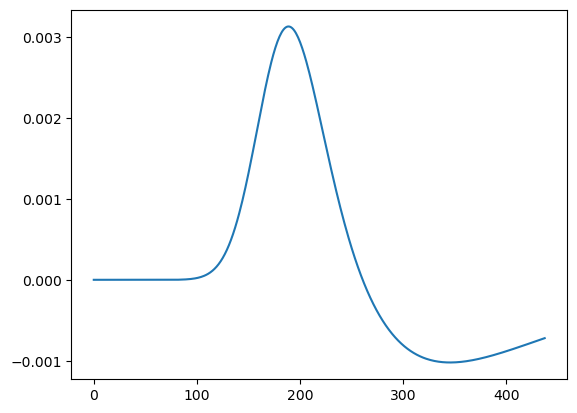

In [98]:
plt.plot((modeler.timeprof_per_component[idf : idf + 2, :, idc] - prof1).sum(0))

In [99]:
test = []
for time in range(ratio2.shape[1]):
    test.append(
        np.all(
            amp1.flatten()
            == amp2[upsample_freq * idf : upsample_freq * idf + 2, time, idc]
        )
    )

np.all(test)

np.False_

In [100]:
mask = np.zeros(prof1.shape)
mask2 = np.zeros(current_times_arr.shape)

In [101]:
mask[..., r1] = 1
mask2[..., r21] = 1

In [102]:
np.all(mask2[upsample_freq * idf : upsample_freq * idf + 2, :, 0] == mask)

np.True_

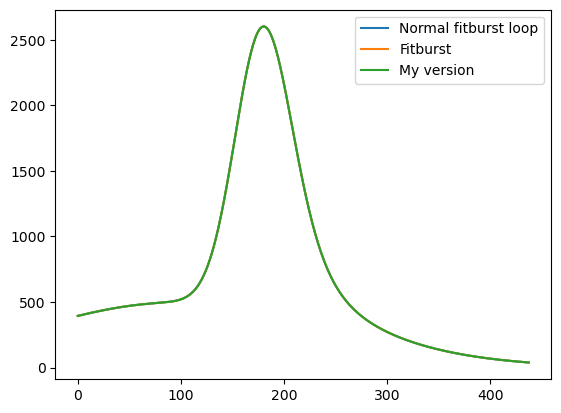

In [103]:
plt.plot(
    downsample_tile(fitburst_prof, (upsample_freq, upsample_time, 1)).sum(2).sum(0),
    label="Normal fitburst loop",
)
plt.plot(modeler.timeprof_per_component.sum(2).sum(0), label="Fitburst")
plt.plot(
    downsample_tile(prof2, (upsample_freq, upsample_time, 1)).sum(2).sum(0),
    label="My version",
)
plt.legend()
plt.show()

In [104]:
test = downsample_tile(prof2, (upsample_freq, upsample_time, 1))

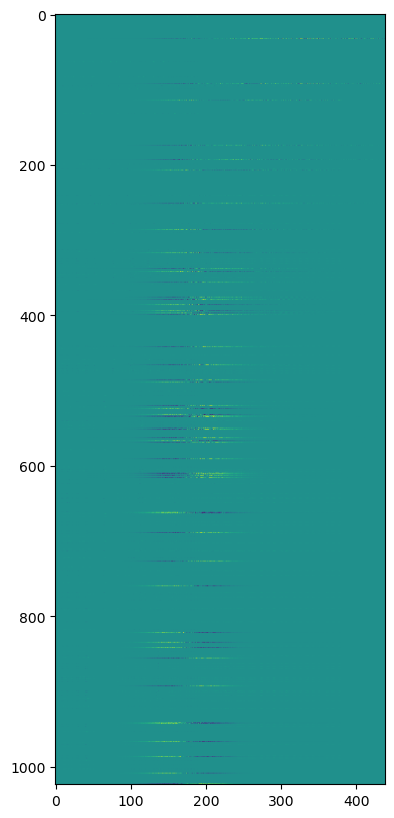

In [105]:
plt.figure(figsize=(10, 10))
plt.imshow((modeler.timeprof_per_component - test).sum(2))

(array([2.8000e+01, 1.7700e+02, 7.4900e+02, 1.3210e+03, 8.8270e+03,
        8.8361e+05, 1.4370e+03, 6.3300e+02, 1.9800e+02, 4.4000e+01]),
 array([-2.66453526e-15, -2.13162821e-15, -1.59872116e-15, -1.06581410e-15,
        -5.32907052e-16,  0.00000000e+00,  5.32907052e-16,  1.06581410e-15,
         1.59872116e-15,  2.13162821e-15,  2.66453526e-15]),
 <BarContainer object of 10 artists>)

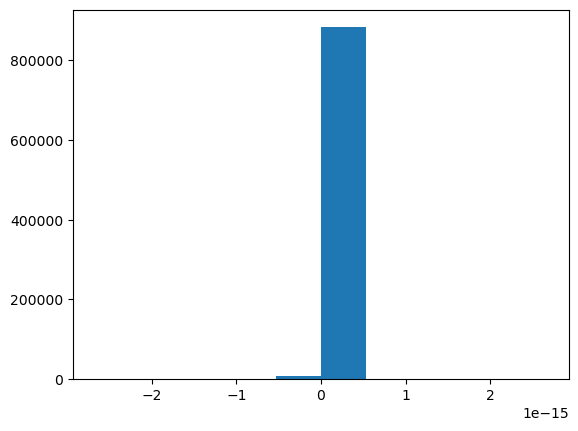

In [106]:
plt.hist((modeler.timeprof_per_component - test).flatten())

### The spectrum?


In [107]:
freq_ratio = current_freq_arr[:, None] / current_ref_freq
exp = np.array(current_sp_idx) + np.array(current_sp_run) * np.log(freq_ratio)
f_kl = np.power(freq_ratio, exp)

In [108]:
updated_prof = prof2 * f_kl[:, None]

In [109]:
downsamp_prof = downsample_tile(updated_prof, (upsample_freq, upsample_time, 1))

In [110]:
final_spectrum = 10**current_amplitudes * downsamp_prof

In [113]:
np.all(np.abs(final_spectrum.sum(2) - modelfitburst) < np.finfo(float).eps)

np.False_

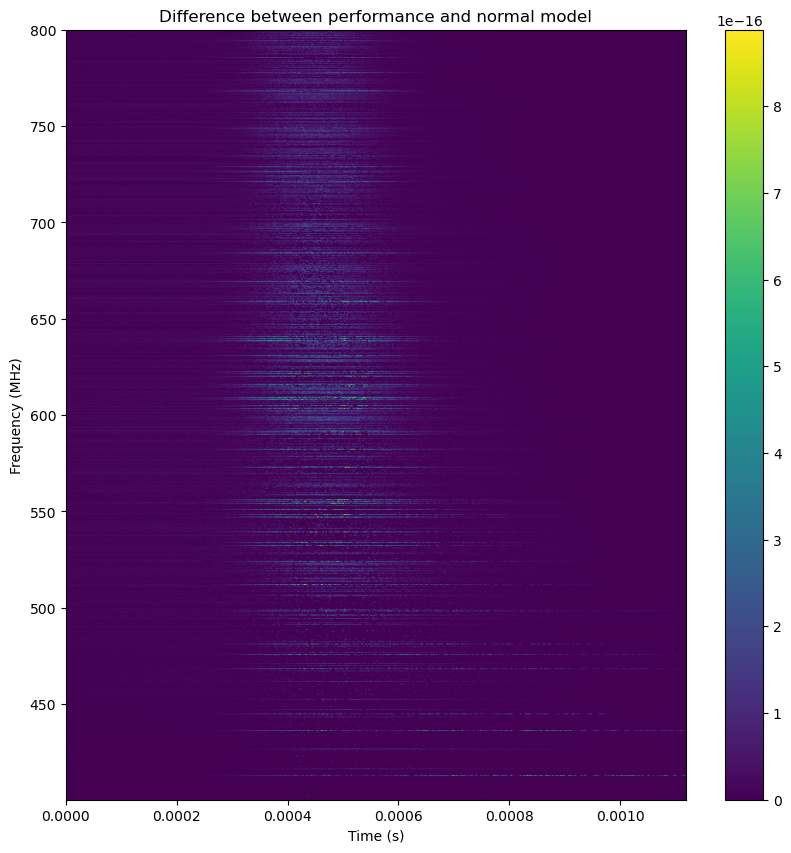

In [111]:
plt.figure(figsize=(10, 10))
plt.imshow(
    np.abs(modelfitburst - final_spectrum.sum(2)),
    aspect="auto",
    extent=[
        times[0],
        times[-1],
        freqs[0],
        freqs[-1],
    ],
    origin="lower",
)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Difference between performance and normal model")
plt.colorbar()